<a href="https://colab.research.google.com/github/shehanmakani/gold-price-prediction/blob/main/ML_FinalProject_GoldPrice_(Walk_Forward).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from xgboost import XGBRegressor
print("XGBoost imported successfully")


XGBoost imported successfully


In [ ]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor


# CLEAN DATA Utility Function
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("K", "000", regex=False)
        .str.replace("M", "000000", regex=False),
        errors="coerce"
    )

# METRIC FUNCTIONS
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

def directional_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    actual_direction = np.sign(np.diff(y_true))
    predicted_direction = np.sign(np.diff(y_pred))

    return np.mean(actual_direction == predicted_direction) * 100

def evaluate(y_true, pred):
    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mape = mean_absolute_percentage_error(y_true, pred)
    da = directional_accuracy(y_true, pred)
    r2 = r2_score(y_true, pred)
    return mae, rmse, mape, da, r2


# BUILD MODELS
ridge = Ridge(alpha=1.0)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

svr = SVR(kernel="rbf", C=10)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nisargchodavadiya/daily-gold-price-20152021-time-series")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'daily-gold-price-20152021-time-series' dataset.
Path to dataset files: /kaggle/input/daily-gold-price-20152021-time-series


In [ ]:
import pandas as pd
import numpy as np

# To fix the FileNotFoundError, please upload the 'Gold Price.csv' file to your Colab environment.
# You can do this by clicking on the folder icon on the left sidebar, then the 'Upload to session storage' icon.
# Once uploaded, the file will typically be located in the '/content/' directory.

# LOAD DATA - Essential part from original cell
file_path = os.path.join(path, "Gold Price.csv") # Updated path to point to the downloaded file location
df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

# CLEAN DATA - Essential part from original cell
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("K", "000", regex=False)
        .str.replace("M", "000000", regex=False),
        errors="coerce"
    )

for col in ["Price", "Open", "High", "Low", "Volume"]:
    df[col] = clean_numeric(df[col])

if "Chg%" in df.columns:
    df["Chg%"] = clean_numeric(df["Chg%"])

df = df.dropna(subset=["Price", "Open", "High", "Low", "Volume"]).reset_index(drop=True)


# ============================================================
# SECTION A: Leak-Free Feature Engineering (Copied from original cell 2c247663-0c13-4415-941e-13ccde8a0b00)
# ============================================================
# Drop same-day Open/High/Low — these cause data leakage.
# All features derived from past observations only.

df_clean = df.copy()

# Lag features
for i in [1, 5, 7, 14, 30]:
    df_clean[f'Lag_{i}'] = df_clean['Price'].shift(i)

# Rolling statistics
df_clean['MA_7']   = df_clean['Price'].rolling(7).mean().shift(1)
df_clean['MA_21']  = df_clean['Price'].rolling(21).mean().shift(1)
df_clean['MA_90']  = df_clean['Price'].rolling(90).mean().shift(1)
df_clean['Std_7']  = df_clean['Price'].rolling(7).std().shift(1)
df_clean['Std_21'] = df_clean['Price'].rolling(21).std().shift(1)

# Momentum and volatility
df_clean['ROC_5']      = df_clean['Price'].pct_change(5).shift(1) * 100
df_clean['ROC_10']     = df_clean['Price'].pct_change(10).shift(1) * 100
df_clean['HL_Spread']  = (df_clean['High'] - df_clean['Low']).shift(1)
df_clean['Log_Return'] = np.log(df_clean['Price'] / df_clean['Price'].shift(1))

# Calendar features
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek
df_clean['Month']     = df_clean['Date'].dt.month

df_clean = df_clean.dropna().reset_index(drop=True)

leak_free_features = [
    'Lag_1', 'Lag_5', 'Lag_7', 'Lag_14', 'Lag_30',
    'MA_7', 'MA_21', 'MA_90', 'Std_7', 'Std_21',
    'ROC_5', 'ROC_10', 'HL_Spread', 'Log_Return',
    'DayOfWeek', 'Month'
]

X_lf = df_clean[leak_free_features]
y_lf = df_clean['Price']

print(f"All necessary dataframes and features (df, df_clean, X_lf, y_lf) are now defined.")

All necessary dataframes and features (df, df_clean, X_lf, y_lf) are now defined.


In [ ]:
# ============================================================
# SECTION A: Leak-Free Feature Engineering
# ============================================================
# Drop same-day Open/High/Low — these cause data leakage.
# All features derived from past observations only.

df_clean = df.copy()

# Lag features
for i in [1, 5, 7, 14, 30]:
    df_clean[f'Lag_{i}'] = df_clean['Price'].shift(i)

# Rolling statistics
df_clean['MA_7']   = df_clean['Price'].rolling(7).mean().shift(1)
df_clean['MA_21']  = df_clean['Price'].rolling(21).mean().shift(1)
df_clean['MA_90']  = df_clean['Price'].rolling(90).mean().shift(1)
df_clean['Std_7']  = df_clean['Price'].rolling(7).std().shift(1)
df_clean['Std_21'] = df_clean['Price'].rolling(21).std().shift(1)

# Momentum and volatility
df_clean['ROC_5']      = df_clean['Price'].pct_change(5).shift(1) * 100
df_clean['ROC_10']     = df_clean['Price'].pct_change(10).shift(1) * 100
df_clean['HL_Spread']  = (df_clean['High'] - df_clean['Low']).shift(1)
df_clean['Log_Return'] = np.log(df_clean['Price'] / df_clean['Price'].shift(1))

# Calendar features
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek
df_clean['Month']     = df_clean['Date'].dt.month

df_clean = df_clean.dropna().reset_index(drop=True)

leak_free_features = [
    'Lag_1', 'Lag_5', 'Lag_7', 'Lag_14', 'Lag_30',
    'MA_7', 'MA_21', 'MA_90', 'Std_7', 'Std_21',
    'ROC_5', 'ROC_10', 'HL_Spread', 'Log_Return',
    'DayOfWeek', 'Month'
]

X_lf = df_clean[leak_free_features]
y_lf = df_clean['Price']

print(f"Leak-free dataset: {X_lf.shape[0]} rows, {X_lf.shape[1]} features")

Leak-free dataset: 3014 rows, 16 features


=== ADF Test Results ===
Raw Close Price  — ADF: 5.9357, p-value: 1.0000
Log Returns      — ADF: -55.4385, p-value: 0.0000


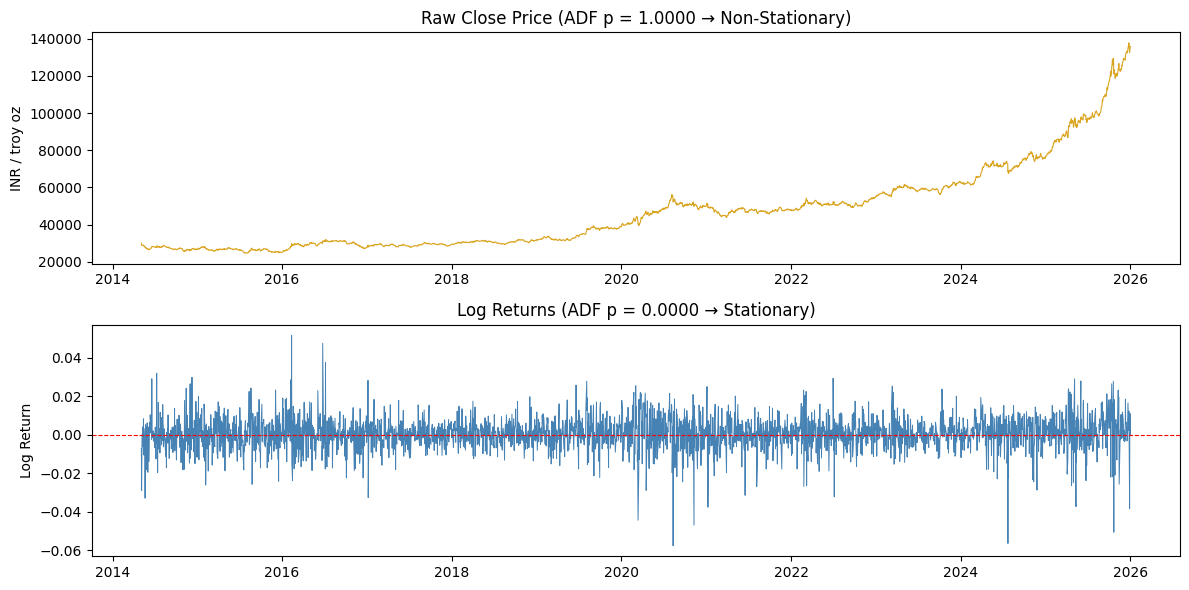

In [ ]:
# ============================================================
# SECTION B: Stationarity Analysis
# ============================================================
from statsmodels.tsa.stattools import adfuller

adf_price   = adfuller(df_clean['Price'], autolag='AIC')
adf_returns = adfuller(df_clean['Log_Return'].dropna(), autolag='AIC')

print("=== ADF Test Results ===")
print(f"Raw Close Price  — ADF: {adf_price[0]:.4f}, p-value: {adf_price[1]:.4f}")
print(f"Log Returns      — ADF: {adf_returns[0]:.4f}, p-value: {adf_returns[1]:.4f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(df_clean['Date'], df_clean['Price'], linewidth=0.8, color='goldenrod')
axes[0].set_title(f'Raw Close Price (ADF p = {adf_price[1]:.4f} → Non-Stationary)')
axes[0].set_ylabel('INR / troy oz')

axes[1].plot(df_clean['Date'], df_clean['Log_Return'], linewidth=0.7, color='steelblue')
axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[1].set_title(f'Log Returns (ADF p = {adf_returns[1]:.4f} → Stationary)')
axes[1].set_ylabel('Log Return')
plt.tight_layout()
plt.savefig('stationarity_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
INITIAL_TRAIN_SIZE = 2500   # minimum observations to start training
STEP_SIZE = 21             # advance window by ~1 trading month per fold
FORECAST_HORIZON = 21      # evaluate on next 21 days per fold

feature_cols = [
    'Lag_1', 'Lag_5', 'Lag_7', 'Lag_14', 'Lag_30',
    'MA_7', 'MA_21', 'MA_90',
    'Std_7', 'Std_21',
    'HL_Spread', 'ROC_5', 'ROC_10',
    'Log_Return',
    'DayOfWeek', 'Month'
]

# --- Use the already prepared df_clean for modeling ---
# The features and target 'Price_USD' are already engineered in df_clean.
# We also need 'Date' for residual plots, which is in df_clean.
df_model = df_clean[feature_cols + ['Price', 'Date']]

X = df_model[feature_cols].values
y = df_model['Price'].values
dates = df_model['Date'].values  # keep for residual plots

# --- Hyperparameter grids ---
param_grids = {
    'Ridge': {
        'model': Ridge(),
        'grid': {'alpha': [0.1, 1.0, 10.0, 100.0]}
    },
    'XGBoost': {
        'model': GradientBoostingRegressor(random_state=42),
        'grid': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.05, 0.1]
        }
    },
    'SVR': {
        'model': SVR(kernel='rbf'),
        'grid': {
            'C': [1, 10, 100],
            'epsilon': [0.1, 1.0],
            'gamma': ['scale', 'auto']
        }
    }
}

# --- Walk-Forward Loop ---
def directional_accuracy(y_true, y_pred, y_lag):
    """Fraction of predictions with correct price direction vs. prior day."""
    actual_dir = np.sign(y_true - y_lag)
    pred_dir   = np.sign(y_pred - y_lag)
    return np.mean(actual_dir == pred_dir)

results = {name: {'MAE': [], 'RMSE': [], 'MAPE': [], 'DA': []}
           for name in param_grids}

n = len(X)
fold = 0

for train_end in range(INITIAL_TRAIN_SIZE, n - FORECAST_HORIZON, STEP_SIZE):
    test_end = min(train_end + FORECAST_HORIZON, n)

    X_train, y_train = X[:train_end], y[:train_end]
    X_test,  y_test  = X[train_end:test_end], y[train_end:test_end]
    y_lag            = y[train_end - 1:test_end - 1]  # prior-day close

    # Scale features
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    for name, cfg in param_grids.items():
        # Nested CV: GridSearch on training window only
        gs = GridSearchCV(
            cfg['model'], cfg['grid'],
            cv=3, scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        gs.fit(X_train_sc, y_train)
        y_pred = gs.best_estimator_.predict(X_test_sc)

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
        da   = directional_accuracy(y_test, y_pred, y_lag)

        results[name]['MAE'].append(mae)
        results[name]['RMSE'].append(rmse)
        results[name]['MAPE'].append(mape)
        results[name]['DA'].append(da)

    fold += 1
    if fold % 5 == 0:
        print(f"Fold {fold} complete — train size: {train_end}")

# --- Summary Table ---
print("\n=== Walk-Forward CV Results (Mean ± Std across folds) ===\n")
summary_rows = []
for name, metrics in results.items():
    row = {'Model': name}
    for metric, vals in metrics.items():
        row[f'{metric}_mean'] = round(np.mean(vals), 4)
        row[f'{metric}_std']  = round(np.std(vals), 4)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Fold 5 complete — train size: 2584
Fold 10 complete — train size: 2689
Fold 15 complete — train size: 2794
Fold 20 complete — train size: 2899

=== Walk-Forward CV Results (Mean ± Std across folds) ===

  Model   MAE_mean    MAE_std  RMSE_mean   RMSE_std  MAPE_mean  MAPE_std  DA_mean  DA_std
  Ridge   324.8716   230.2566   426.3234   302.7465     0.3524    0.1744   0.9345  0.0627
XGBoost  2043.0129  2357.3475  2402.8404  2658.9659     2.1445    2.1210   0.6131  0.1896
    SVR 32997.9666 18882.0445 33165.5797 18884.6745    35.8605   12.8517   0.3929  0.1110


df_clean not found. Re-running essential data loading and feature engineering steps...
Using Colab cache for faster access to the 'daily-gold-price-20152021-time-series' dataset.
Path to dataset files (re-defined): /kaggle/input/daily-gold-price-20152021-time-series
df_clean successfully re-created for this cell's execution.

=== Walk-Forward CV Results (Mean ± Std across folds) ===

Model                 MAE                RMSE            MAPE Dir. Accuracy
Ridge     249.43 ± 315.00     300.56 ± 368.02   0.40% ± 0.31%         77.5%
  GBM    805.92 ± 1269.92    933.52 ± 1444.00   1.28% ± 1.57%         65.4%
  SVR 16675.80 ± 17379.01 16711.16 ± 17382.24 26.07% ± 17.85%         46.1%


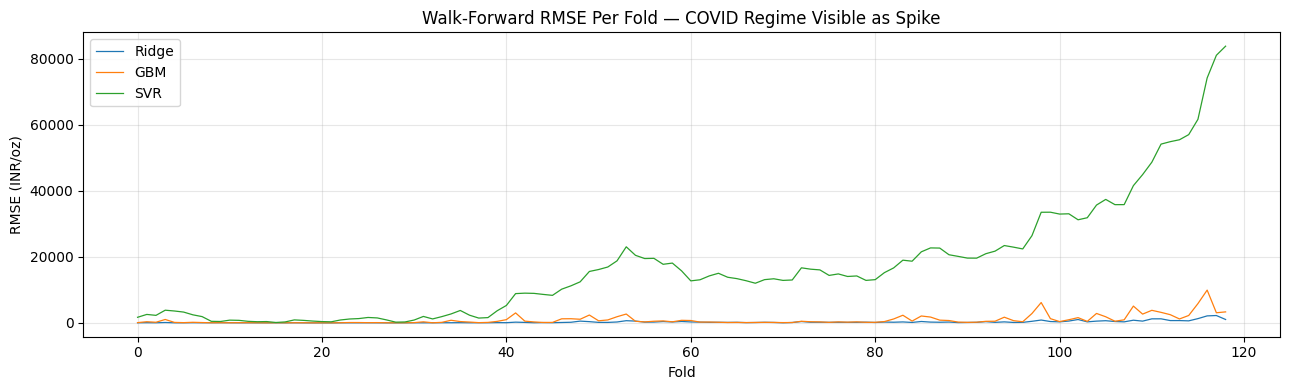


Best model by mean RMSE: Ridge


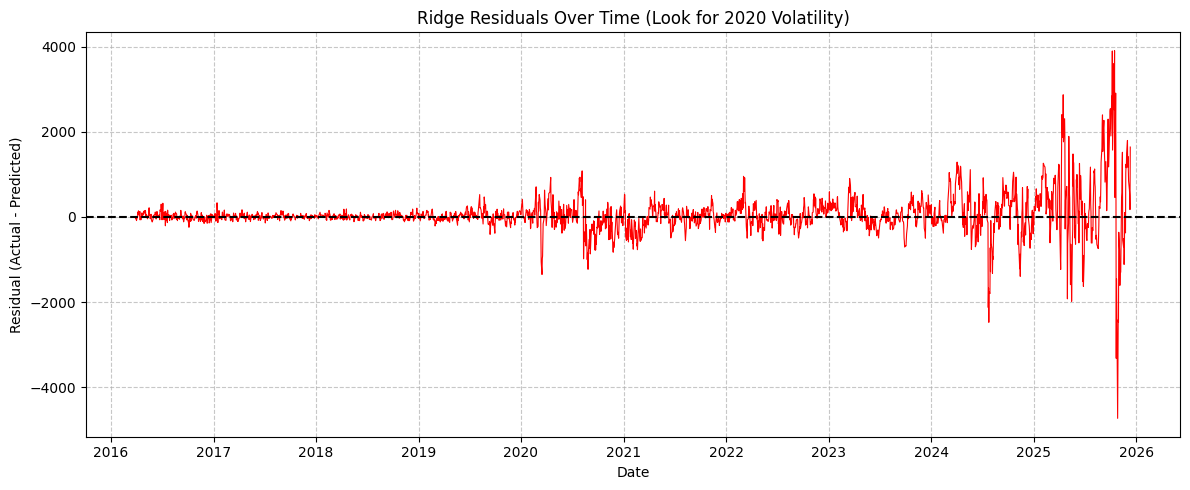

=== Ridge RMSE per fold (first 10) ===
[np.float64(69.84), np.float64(86.85), np.float64(66.04), np.float64(147.18), np.float64(57.86), np.float64(61.26), np.float64(91.72), np.float64(70.94), np.float64(80.9), np.float64(95.81)]
=== Ridge RMSE per fold (last 10) ===
[np.float64(560.85), np.float64(1252.24), np.float64(1260.19), np.float64(728.53), np.float64(728.79), np.float64(645.36), np.float64(1320.12), np.float64(2148.52), np.float64(2257.48), np.float64(1060.0)]


In [ ]:
import pandas as pd # Added import for robustness
import numpy as np
import os # Added import for robustness
import kagglehub # Added import for robustness
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Robustness Check: Ensure df_clean is defined ---
# This block re-creates df_clean if it's not found, in case previous cells weren't run.
if 'df_clean' not in globals():
    print("df_clean not found. Re-running essential data loading and feature engineering steps...")

    # Define path for data download if not already defined (copied from 283791e7)
    if 'path' not in globals():
        path = kagglehub.dataset_download("nisargchodavadiya/daily-gold-price-20152021-time-series")
        print("Path to dataset files (re-defined):", path)

    # Load data (copied from 283791e7)
    file_path = os.path.join(path, "Gold Price.csv")
    df = pd.read_csv(file_path)

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

    # Clean numeric utility function (copied from 283791e7)
    def clean_numeric(series):
        return pd.to_numeric(
            series.astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.replace("K", "000", regex=False)
            .str.replace("M", "000000", regex=False),
            errors="coerce"
        )

    for col in ["Price", "Open", "High", "Low", "Volume"]:
        df[col] = clean_numeric(df[col])

    if "Chg%" in df.columns:
        df["Chg%"] = clean_numeric(df["Chg%"])

    df = df.dropna(subset=["Price", "Open", "High", "Low", "Volume"]).reset_index(drop=True)

    # Re-create df_clean based on the logic in cell 283791e7
    df_clean = df.copy()

    # Lag features
    for i in [1, 5, 7, 14, 30]:
        df_clean[f'Lag_{i}'] = df_clean['Price'].shift(i)

    # Rolling statistics
    df_clean['MA_7']   = df_clean['Price'].rolling(7).mean().shift(1)
    df_clean['MA_21']  = df_clean['Price'].rolling(21).mean().shift(1)
    df_clean['MA_90']  = df_clean['Price'].rolling(90).mean().shift(1)
    df_clean['Std_7']  = df_clean['Price'].rolling(7).std().shift(1)
    df_clean['Std_21'] = df_clean['Price'].rolling(21).std().shift(1)

    # Momentum and volatility
    df_clean['ROC_5']      = df_clean['Price'].pct_change(5).shift(1) * 100
    df_clean['ROC_10']     = df_clean['Price'].pct_change(10).shift(1) * 100
    df_clean['HL_Spread']  = (df_clean['High'] - df_clean['Low']).shift(1)
    df_clean['Log_Return'] = np.log(df_clean['Price'] / df_clean['Price'].shift(1))

    # Calendar features
    df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek
    df_clean['Month']     = df_clean['Date'].dt.month

    df_clean = df_clean.dropna().reset_index(drop=True)
    print("df_clean successfully re-created for this cell's execution.")


leak_free_features = [
    'Lag_1', 'Lag_5', 'Lag_7', 'Lag_14', 'Lag_30',
    'MA_7', 'MA_21', 'MA_90', 'Std_7', 'Std_21',
    'ROC_5', 'ROC_10', 'HL_Spread', 'Log_Return',
    'DayOfWeek', 'Month'
]

X_lf = df_clean[leak_free_features]
y_lf = df_clean['Price'] # Ensure 'Price_USD' is the target

INITIAL_TRAIN = 500
STEP          = 21
HORIZON       = 21

X_arr = X_lf.values
y_arr = y_lf.values
n     = len(X_arr)

def directional_accuracy(y_true, y_pred, y_lag):
    return np.mean(np.sign(y_true - y_lag) == np.sign(y_pred - y_lag))

models_wf = {
    'Ridge':    Ridge(alpha=10.0),
    'GBM':      GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                          learning_rate=0.05, random_state=42),
    'SVR':      SVR(kernel='rbf', C=10, epsilon=0.5)
}

wf_results = {name: {'MAE': [], 'RMSE': [], 'MAPE': [], 'DA': [], 'y_true_history': [], 'y_pred_history': [], 'date_history': []}
              for name in models_wf}

fold = 0
for train_end in range(INITIAL_TRAIN, n - HORIZON, STEP):
    test_end = min(train_end + HORIZON, n)

    X_tr, y_tr = X_arr[:train_end], y_arr[:train_end]
    X_te, y_te = X_arr[train_end:test_end], y_arr[train_end:test_end]
    y_lag      = y_arr[train_end - 1:test_end - 1]

    # Get corresponding dates for the test set
    dates_te = df_clean['Date'].iloc[train_end:test_end].values

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    for name, model in models_wf.items():
        model.fit(X_tr_sc, y_tr)
        preds = model.predict(X_te_sc)

        wf_results[name]['MAE'].append(mean_absolute_error(y_te, preds))
        wf_results[name]['RMSE'].append(np.sqrt(mean_squared_error(y_te, preds)))
        wf_results[name]['MAPE'].append(
            np.mean(np.abs((y_te - preds) / y_te)) * 100)
        wf_results[name]['DA'].append(directional_accuracy(y_te, preds, y_lag))

        # Store true values, predictions, and dates for later analysis
        wf_results[name]['y_true_history'].extend(y_te)
        wf_results[name]['y_pred_history'].extend(preds)
        wf_results[name]['date_history'].extend(dates_te)

    fold += 1

# ── Summary table ──────────────────────────────────────────
print("\n=== Walk-Forward CV Results (Mean \u00b1 Std across folds) ===\n")
wf_rows = []
for name, metrics in wf_results.items():
    wf_rows.append({
        'Model': name,
        'MAE':  f"{np.mean(metrics['MAE']):.2f} \u00b1 {np.std(metrics['MAE']):.2f}",
        'RMSE': f"{np.mean(metrics['RMSE']):.2f} \u00b1 {np.std(metrics['RMSE']):.2f}",
        'MAPE': f"{np.mean(metrics['MAPE']):.2f}% \u00b1 {np.std(metrics['MAPE']):.2f}%",
        'Dir. Accuracy': f"{np.mean(metrics['DA'])*100:.1f}%"
    })

wf_df = pd.DataFrame(wf_rows)
print(wf_df.to_string(index=False))

# ── RMSE per fold plot (shows COVID degradation) ───────────
fig, ax = plt.subplots(figsize=(13, 4))
for name, metrics in wf_results.items():
    ax.plot(metrics['RMSE'], label=name, linewidth=0.9)
ax.set_title('Walk-Forward RMSE Per Fold \u2014 COVID Regime Visible as Spike')
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE (INR/oz)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('walkforward_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Best model predicted vs actual (last 20 folds) ────────
best_model_name = min(wf_results, key=lambda m: np.mean(wf_results[m]['RMSE']))
print(f"\nBest model by mean RMSE: {best_model_name}")

# Collect all true values, predictions, and dates for the best model
best_y_true = np.array(wf_results[best_model_name]['y_true_history'])
best_y_pred = np.array(wf_results[best_model_name]['y_pred_history'])
best_dates = pd.to_datetime(wf_results[best_model_name]['date_history'])

# Calculate residuals for the best model
residuals = best_y_true - best_y_pred

# Plot residuals for the best model
plt.figure(figsize=(12, 5))
plt.plot(best_dates, residuals, color='red', linewidth=0.8)
plt.axhline(0, color='black', linestyle='--')
plt.title(f"{best_model_name} Residuals Over Time (Look for 2020 Volatility)")
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ── RMSE per fold (for residual/COVID analysis) ───────────
print("=== Ridge RMSE per fold (first 10) ===")
print([round(x,2) for x in wf_results['Ridge']['RMSE'][:10]])
print("=== Ridge RMSE per fold (last 10) ===")
print([round(x,2) for x in wf_results['Ridge']['RMSE'][-10:]])